# Test the statistical method for different scenario

In [8]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
c0 ={'acc':'#941717', 'cor':'#388E3C','ggd':'#42A5F5', 'wd':'#FFA000', 'sum':'lightgrey'}
plt.rcParams["hatch.linewidth"] = 8
from diagnosis import compute_mean_square, put_fig_letter

images_dir = '/Users/mdemol/ownCloud/PhD/images/images_methodo'

In [2]:
N=1000000

In [3]:
closure_vars = ['ACC*', 'COR*', 'GGD*', 'WD*', 'S*', 'sigma*'] + ['B*_'+v for v in ['acc', 'cor', 'ggd', 'wd']] + ['E*_'+v for v in ['acc', 'cor', 'ggd', 'wd']] + ['X*_acc_cor', 'X*_acc_ggd', 'X*_acc_wd', 'X*_cor_ggd', 'X*_cor_wd', 'X*_ggd_wd'] + ['D*_cyclo', 'D*_anticyclo']

def compute_mean_square_1D(ds, null_mean = True):
    """ Compute closure stats
    ds : dataset containing terms values for all row_numbers
    dirname : directions of the reconstruction
    """
    ds = ds.copy()
    closure_vars_=closure_vars
    
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']

    if null_mean :
        for v in var :
            ds['mean_'+v] = ds[v].mean('row_number')
            ds[v] = ds[v] - ds[v].mean('row_number')
            add_exc_sum_prod(ds)
        
    dss = (ds[[v for v in var]]**2).rename({var[i] : VAR[i] for i in range(len(var))})
    dss['sigma'] = dss['ACC'] + dss['COR'] + dss['GGD'] + dss['WD']
    
    nb_coloc = len(ds.row_number)
    
    #Balanced and error

    for v in ['acc', 'cor', 'ggd', 'wd'] : 
        dss['B'+'_'+v] = -((ds[v]*ds['exc'+'_'+v]))
        dss['E'+'_'+v] = ((ds[v]*ds['sum']))
            
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v]

    # Cyclo/anticyclo contribution
    dss['D'+'_cyclo'] = -2 *(ds['acc']+ds['cor'])*ds['ggd']
    dss['D'+'_anticyclo'] = -2 *(ds['acc']+ds['ggd'])*ds['cor']

    # Mean
    dsm = dss.mean('row_number')
    
    # Add errors central limit
    dsse = (2*dss.std('row_number')/np.sqrt(nb_coloc)).rename({v:'ser__'+v for v in list(dss.keys())})

    dss = xr.merge([dsm, dsse])

    from diagnosis import assign_attrs
    dss = assign_attrs(dss,[''])
    return dss

def add_exc_sum_prod(ds):
    ds['sum'] = ds.acc + ds.cor + ds.ggd +ds.wd

    # simple var + sum- one term
    for v in ['acc', 'cor', 'ggd', 'wd'] :
        ds['exc_'+v] = ds['sum']-ds[v]

    #2 by 2 product    
    import itertools  
    couple = list(itertools.combinations(['acc', 'cor', 'ggd', 'wd'],2))
    for c in couple : 
        ds['prod'+'_'+'_'.join(c)] = ds[c[0]] * ds[c[1]]
        
def build_dataset(a, b, c, d, row):
    ds = xr.Dataset(
        data_vars=dict(
            acc=("row_number", a),
            cor=("row_number", b),
            ggd=("row_number", c),
            wd=("row_number", d),
        ), 
        coords=dict(row_number=("row_number", row)
                   )
    )
    add_exc_sum_prod(ds)
    
    return ds

def plot_terms(ds):
    fig, axs = plt.subplots(1, 5, sharey=True, frameon=False, figsize=(10,3))
    i=0
    for var in ['acc', 'cor','ggd','wd', 'sum']:
        ds[var].plot(ax=axs[i], color = c0[var])
        i+=1
    for ax in axs :
        ax.grid()


def plot_diag(fig, ax, ds, ds2):
    plt.rcParams["axes.edgecolor"] = "k"
    df = ds.to_dataframe()
    var = ['acc', 'cor', 'ggd', 'wd']
    i=0
    for v in var:
        ## total MS
        #ax.bar(i, ds2[v.upper()], color=c0[v], alpha=0.5)
    
        #B and E
        w =0.8
        if ds2['B_'+v] > 0 : 
            ax.bar(i, ds2['B_'+v], color=c0[v], width=w)
            if ds2['E_'+v]< 0 :
                print('E_neg')
                ax.bar(i, ds2['E_'+v], color='lightgrey', width=w)
            else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=w)
        else :
            print('B_neg'+v)
            ax.bar(i, ds2['B_'+v], color=c0[v], width=w)
            if ds2['E_'+v]>0 : ax.bar(i, ds2['E_'+v], color='lightgrey', width=w)
            else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=w)
                
        #X
        w =0.4
        X_var = [x for x in ds2 if (('X_' in x)&(v in x)&('ser_' not in x))]
        pos_X = [ x for x in X_var if ds2[x]>0]
        neg_X = [ x for x in X_var if x not in pos_X]
    
        sum_posX = 0
        for X in pos_X :
            xc =X.replace('X_', '').split('_')
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X]/2, bottom = sum_posX, color = c0[xc[1]], hatch="/", width=w)
            sum_posX += ds2[X]/2
    
        sum_negX = 0
        for X in neg_X :
            xc =X.replace('X_', '').split('_')
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X]/2, bottom = sum_negX, color = c0[xc[1]], hatch="/", width=w)
            sum_negX += ds2[X]/2
        i+=1
    ax.bar(i, ds2['S'], color = 'lightgrey')
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    

def plot_total_diag_pp(a, b, c, d, row, null_mean=True):
    
    ds = build_dataset(a, b, c, d, row)

    ds['row_number'] = ds['row_number'].assign_attrs({'long_name':'Colocations'})
    ds['acc'] = ds['acc'].assign_attrs({'long_name':'Lagrangian acceleration', 'unit':r'$\gamma$'})
    ds['cor'] = ds['cor'].assign_attrs({'long_name':'Coriolis acceleration ', 'unit':r'$\gamma$'})
    ds['ggd'] = ds['ggd'].assign_attrs({'long_name':'Pressure gradient term', 'unit':r'$\gamma$'})
    ds['wd'] = ds['wd'].assign_attrs({'long_name':'Wind term', 'unit':r'$\gamma$'})
    ds['sum'] = ds['sum'].assign_attrs({'long_name':'Residual', 'unit':r'$\gamma$'})

    ds2 = compute_mean_square_1D(ds, null_mean)

    from matplotlib.gridspec import GridSpec
    fig = plt.figure( frameon=False, figsize = (8, 2))
    gs = GridSpec(2, 5, figure=fig)

    # Visualize row series
    i=0
    ax0 = fig.add_subplot(gs[0, i])
    for var in ['acc', 'cor','ggd','wd', 'sum']:
        ax = fig.add_subplot(gs[0, i], sharey=ax0)
        ds[var].plot(ax=ax, color = c0[var])
        ax.axhline(ds[var].mean(dim='row_number'), ls = '--', color='k')
        ax.set_ylabel('')
        ax.set_xlabel('Colocations')
        ax.grid()
        i+=1
    # Reconstruction data
    ax = fig.add_subplot(gs[1, :])
    plot_diag(fig, ax, ds, ds2)
    ax.set_xticks(ticks = np.arange(5),labels =['Lagrangian \n acceleration', 'Coriolis \n acceleration', 'Pressure \n gradient term', 'Wind','Residual'])
    #ax.set_xticks(ticks = np.arange(5),labels = ['A', 'B', 'C', 'D','Residual'] )
    fig.tight_layout()
    
    return ds, ds2


def plot_total_diag(a, b, c, d, row, null_mean=True):
    
    ds = build_dataset(a, b, c, d, row)

    ds['row_number'] = ds['row_number'].assign_attrs({'long_name':'Colocations'})
    ds['acc'] = ds['acc'].assign_attrs({'long_name':'Lagrangian acceleration', 'unit':r'$\gamma$'})
    ds['cor'] = ds['cor'].assign_attrs({'long_name':'Coriolis acceleration ', 'unit':r'$\gamma$'})
    ds['ggd'] = ds['ggd'].assign_attrs({'long_name':'Pressure gradient term', 'unit':r'$\gamma$'})
    ds['wd'] = ds['wd'].assign_attrs({'long_name':'Wind term', 'unit':r'$\gamma$'})
    ds['sum'] = ds['sum'].assign_attrs({'long_name':'Residual', 'unit':r'$\gamma$'})

    ds2 = compute_mean_square_1D(ds, null_mean)

    from matplotlib.gridspec import GridSpec
    fig = plt.figure( frameon=False, figsize = (8, 3))
    gs = GridSpec(1, 3, figure=fig)

    # Visualize row series
    i=0
    ax = fig.add_subplot(gs[0, 0])
    for var in ['acc', 'cor','ggd','wd', 'sum']:
        if (ds[var].max()<1e-10) & (ds[var].min()>-1e-10): continue
        hist, bins = np.histogram(ds[var],bins=100)
        bins = (bins[1:]+bins[:-1])/2
        ax.plot(bins, hist, color = c0[var])
        #ax.axvline(ds[var].mean(), color = c0[var], ls='--')
        #ax.axvline(ds[var].mean()+ds[var].std(), color = c0[var], ls=':')
    ax.set_ylabel('PDF')
    ax.set_yticks(ticks = [], labels=[])
    ax.set_xlabel(r'[$\gamma$]')
    ax.grid()
        
    # Reconstruction data
    ax = fig.add_subplot(gs[0, 1:])
    plot_diag(fig, ax, ds, ds2)
    ax.set_xticks(ticks = np.arange(5),labels =['Lagrangian \n acceleration', 'Coriolis \n acceleration', 'Pressure \n gradient term', 'Wind','Residual'])
    ax.set_ylim(-2, 20)
    #ax.set_xticks(ticks = np.arange(5),labels = ['A', 'B', 'C', 'D','Residual'] )
    fig.tight_layout()
    
    return ds, ds2, fig

__________________________
# 1. No errors
## 1.1. First case : Mean =0; 4 uncorrelated terms - no errors

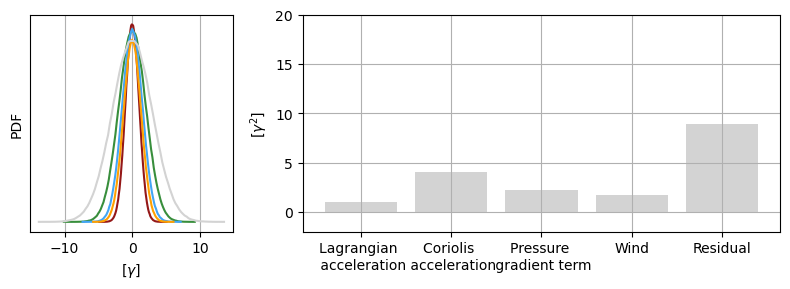

In [9]:
std = [1, 2, 1.5, 1.3]
mean = [0,0,0,0]
row = np.arange(0, N)

a = np.random.normal(0, std[0], N)
b = np.random.normal(0, std[1], N)
c = np.random.normal(0, std[2], N)
#d=-b
d = np.random.normal(0, std[3], N)

ds, ds2, fig = plot_total_diag(a, b, c, d, row, null_mean=True)


In [6]:
kwargs = {'x':'0.05', 'y':'0.92', 'ha':'left'}

## 1.2. Second case : Pure geostrophy

B_negacc
B_negwd


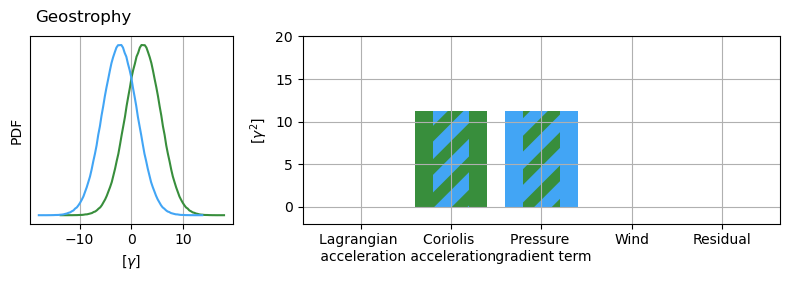

In [25]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)

bc = np.random.normal(mean[1], std[1], N)
bcmiss = np.random.normal(mean[1]*0.5, std[1]*0.5, N)

a = np.zeros(N)#np.random.normal(0, std[0], N)
b = bc+bcmiss
c = -bc-bcmiss
d = np.zeros(N)
#d = np.random.normal(0, std[3], N)

ds, ds2, fig = plot_total_diag(a, b, c, d, row)
fig.suptitle('Geostrophy', **kwargs)
fig.tight_layout()
fig.savefig(images_dir+'/geostrophy.png')

## 1.3. Third case : Ekman

B_negacc
B_negggd


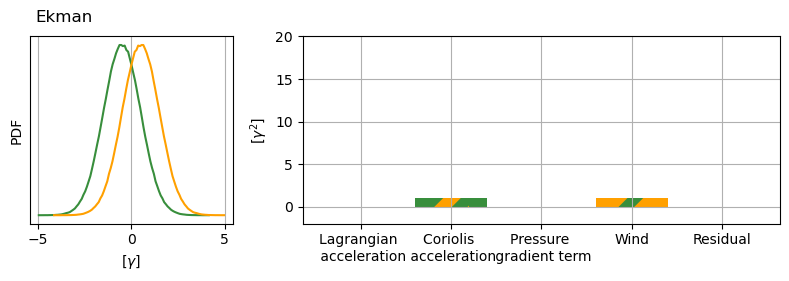

In [26]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.zeros(N)#np.random.normal(0, std[0], N)
bc = np.zeros(N)#np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)
bcmiss = np.zeros(N)#np.random.normal(mean[0]*0.5, std[0]*0.5, N)

a = ab
b = bc-bd-ab+bcmiss
c = -bc-bcmiss
d = bd
#d = np.random.normal(0, std[3], N)

ds, ds2, fig = plot_total_diag(a, b, c, d, row)
fig.suptitle('Ekman',**kwargs)
fig.tight_layout()
fig.savefig(images_dir+'/ekman.png')

## 1.4. Fourth case : Inertial balance

B_negggd
B_negwd


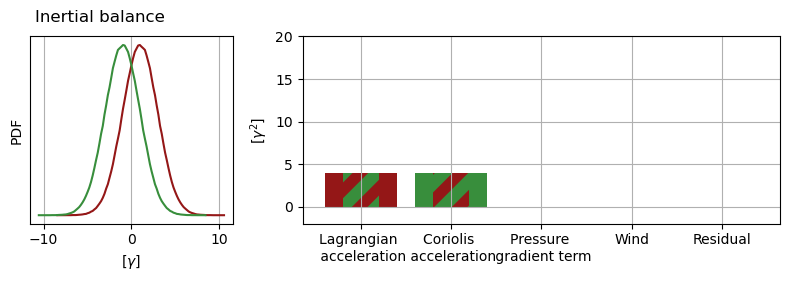

In [27]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(mean[0], std[0], N)
bc = np.zeros(N)#np.random.normal(mean[1], std[1], N)
bd = np.zeros(N)#np.random.normal(mean[2], std[2], N)
bcmiss = np.zeros(N)#np.random.normal(mean[0]*0.5, std[0]*0.5, N)

a = ab
b = bc-bd-ab+bcmiss
c = -bc-bcmiss
d = bd
#d = np.random.normal(0, std[3], N)

ds, ds2, fig = plot_total_diag(a, b, c, d, row)
fig.suptitle('Inertial balance',**kwargs)
fig.tight_layout()
fig.savefig(images_dir+'/inertialbalance.png')


## 1.5. Fifth case : Geostrophy + Ekman + inertial

E_neg
E_neg
E_neg


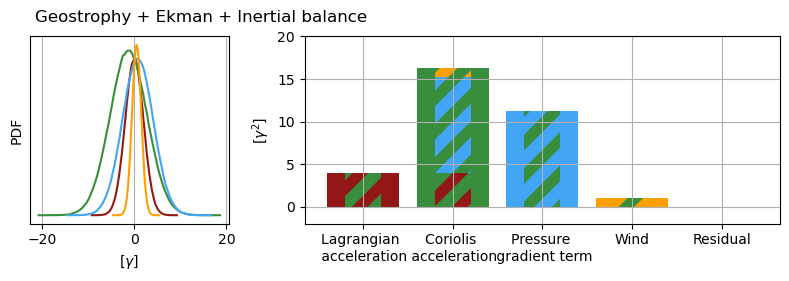

In [28]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(0, std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)
bcmiss = np.random.normal(mean[1]*0.5, std[1]*0.5, N)
a = ab
b = -bc-bd-ab+bcmiss
c = bc-bcmiss
d = bd
#d = np.random.normal(0, std[3], N)

ds, ds2, fig = plot_total_diag(a, b, c, d, row)
fig.suptitle('Geostrophy + Ekman + Inertial balance', **kwargs)
fig.tight_layout()
fig.savefig(images_dir+'/geostrophy_ekman_inertial.png')


## 1.5. Fifth case : Geostrophy + Ekman + inertial + whitenoise

E_neg
E_neg
E_neg


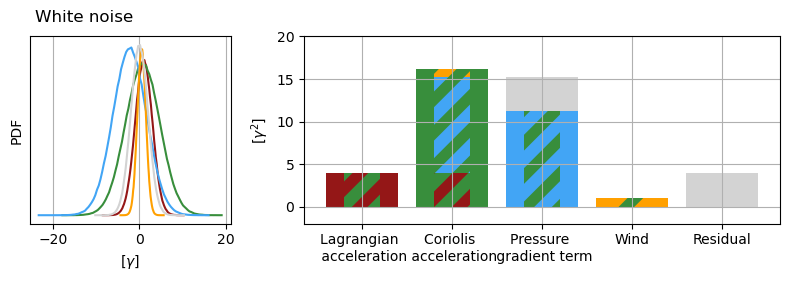

In [17]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)
stdnoise = [0, 0, 2, 0]#[1,0.5,2,0]

mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(mean[0], std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)
bcmiss = np.random.normal(mean[1]*0.5, std[1]*0.5, N)

a = ab +np.random.normal(0, stdnoise[0], N)
b = bc-ab-bd +bcmiss +np.random.normal(0, stdnoise[1], N)
c = -bc+np.random.normal(0, stdnoise[2], N)-bcmiss
d = bd+np.random.normal(0, stdnoise[3], N)
#d = np.random.normal(0, std[3], N)

ds, ds2, fig = plot_total_diag(a, b, c, d, row)
fig.suptitle('White noise', **kwargs)
fig.tight_layout()
fig.savefig(images_dir+'/geostrophy_ekman_inertial_whitenoise.png')


## 1.6. Fifth case : Geostrophy + Ekman + inertial + accuracy error Wind*2

E_neg


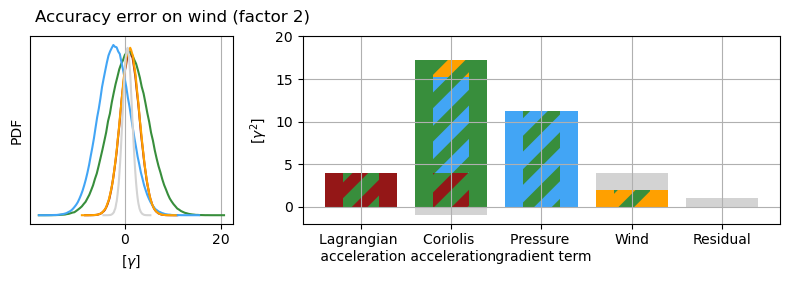

In [22]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)
#stdnoise = [1,0.5,2,0]

mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(mean[0], std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)
bcmiss = np.random.normal(mean[1]*0.5, std[1]*0.5, N)

a = ab #+np.random.normal(0, stdnoise[0], N)
b = bc-ab-bd+bcmiss #+np.random.normal(0, stdnoise[1], N)
c = -bc-bcmiss#+np.random.normal(0, stdnoise[2], N)
d = bd#+np.random.normal(0, stdnoise[3], N)
#d = np.random.normal(0, std[3], N)2
d = d*2

ds, ds2, fig = plot_total_diag(a, b, c, d, row)
fig.suptitle('Accuracy error on wind (factor 2)', **kwargs)
fig.tight_layout()
fig.savefig(images_dir+'/geostrophy_ekman_accuracy_wind.png')


## 1.7. Seventh case : Geostrophy + Ekman + inertial + omission error

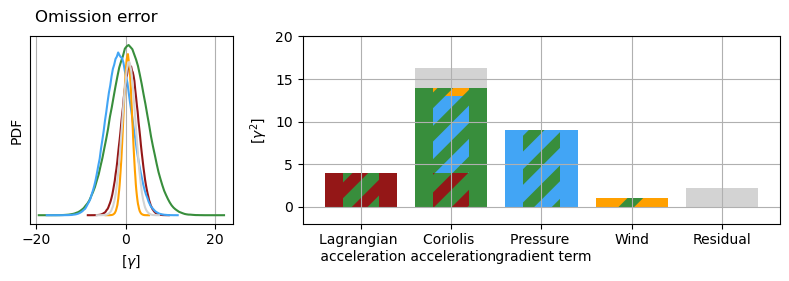

In [21]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)
#stdnoise = [1,0.5,2,0]

mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(mean[0], std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)
bcmiss = np.random.normal(mean[1]*0.5, std[1]*0.5, N)


a = ab #+np.random.normal(0, stdnoise[0], N)+bcmiss
b = bc-ab-bd +bcmiss#+np.random.normal(0, stdnoise[1], N)
c = -bc#+np.random.normal(0, stdnoise[2], N)
d = bd#+np.random.normal(0, stdnoise[3], N)
#d = np.random.normal(0, std[3], N)

ds, ds2, fig = plot_total_diag(a, b, c, d, row)
fig.suptitle('Omission error',  **kwargs)
fig.tight_layout()
fig.savefig(images_dir+'/geostrophy_ekman_inertial_omissionerror.png')


## 1.8. eighth case : Geostrophy + Ekman + inertial + all error types

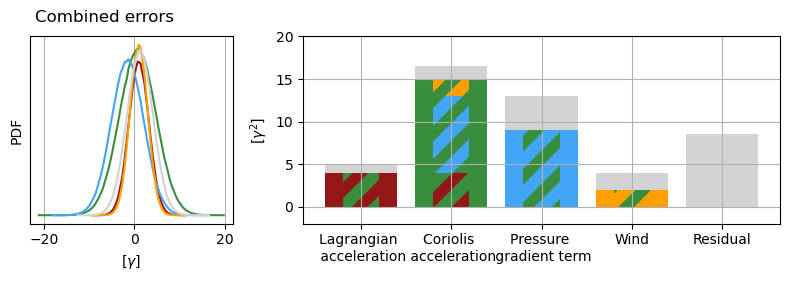

In [23]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)
stdnoise = [1,0.5,2,0]

mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(mean[0], std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)
bcmiss = np.random.normal(mean[1]*0.5, std[1]*0.5, N)


a = ab +np.random.normal(0, stdnoise[0], N)
b = bc-ab-bd + bcmiss+np.random.normal(0, stdnoise[1], N)
c = -bc+np.random.normal(0, stdnoise[2], N)
d = bd+np.random.normal(0, stdnoise[3], N)

d=d*2


ds, ds2, fig = plot_total_diag(a, b, c, d, row)
fig.suptitle('Combined errors', **kwargs)
fig.tight_layout()
fig.savefig(images_dir+'/geostrophy_ekman_inertial_allerrorstype.png')

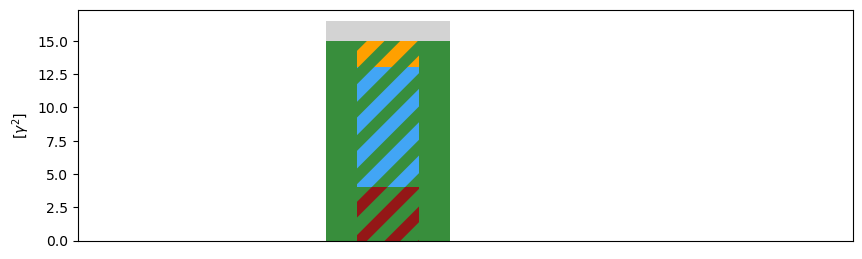

In [24]:


fig, ax = plt.subplots(frameon =False, figsize=(10, 3))
w =0.8
v='cor'
i=2
if ds2['B_'+v] > 0 : 
    ax.bar(i, ds2['B_'+v], color=c0[v], width=w)
    if ds2['E_'+v]< 0 :
        print('E_neg')
        ax.bar(i, ds2['E_'+v], color='lightgrey', width=w)
    else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=w)
else :
    print('B_neg'+v)
    ax.bar(i, ds2['B_'+v], color=c0[v], width=w)
    if ds2['E_'+v]>0 : ax.bar(i, ds2['E_'+v], color='lightgrey', width=w)
    else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=w)
        
#X
w =0.4
X_var = [x for x in ds2 if (('X_' in x)&(v in x)&('ser_' not in x))]
pos_X = [ x for x in X_var if ds2[x]>0]
neg_X = [ x for x in X_var if x not in pos_X]

sum_posX = 0
for X in pos_X :
    xc =X.replace('X_', '').split('_')
    plt.rcParams["hatch.color"] = c0[xc[0]]
    ax.bar(i, ds2[X]/2, bottom = sum_posX, color = c0[xc[1]], hatch="/", width=w)
    sum_posX += ds2[X]/2

sum_negX = 0
for X in neg_X :
    xc =X.replace('X_', '').split('_')
    plt.rcParams["hatch.color"] = c0[xc[0]]
    ax.bar(i, ds2[X]/2, bottom = sum_negX, color = c0[xc[1]], hatch="/", width=w)
    sum_negX += ds2[X]/2
i+=1
ax.set_xlim(0, 5)
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = [], labels=[])

fig.savefig(images_dir+'/example.png')